In [1]:
import numpy as np
import os
import sys
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd


def get_mutations_from_csv_for_n_parents(n_parents, csv_path):
    """
    CSV contains columns: position, parent, mutant
    Rows are sorted by parent (all rows of parent 1 first, then parent 2, etc).
    For each parent group, extract a list of triples:
        (parent_aa, mutant_aa, position)
    where parent_aa = parent[position-1], mutant_aa = mutant[position-1].
    Returns: list of n lists of triples.
    """
    df = pd.read_csv(csv_path)

    mutations_per_parent = []
    parents = []
    i = 0
    idx = 0
    total_rows = len(df)

    while i < n_parents and idx < total_rows:
        current_parent = df.iloc[idx]["parent"]
        parents.append(current_parent)
        group = []
        while idx < total_rows and df.iloc[idx]["parent"] == current_parent:
            row = df.iloc[idx]
            pos = int(row["position"])  # assume 1-based indexing

            parent_aa = row["parent"][pos]
            mutant_aa = row["mutant"][pos]

            group.append((parent_aa, mutant_aa, pos))
            idx += 1

        mutations_per_parent.append(group)
        i += 1

    return mutations_per_parent, parents

In [ ]:
get_mutations_from_csv_for_n_parents(
    5,
    "/home/kjurasz/pep-compass/results/mutants/mutants/hydramp/dbaasp/all/high_saureus_activity_parentleq25_direction_threshold=1e-06_token_threshold=0.1_jacobian_mode=approx_jacobian_eps=0.05_leq25.csv",
)

([[('T', 'H', 7),
   ('T', 'I', 7),
   ('T', 'L', 7),
   ('L', 'E', 9),
   ('L', 'N', 9),
   ('L', 'N', 4),
   ('L', 'N', 1),
   ('L', 'N', 8)],
  [('I', 'P', 4),
   ('I', 'F', 4),
   ('I', 'H', 4),
   ('I', 'N', 4),
   ('I', 'T', 4),
   ('D', 'E', 3),
   ('D', 'S', 3),
   ('D', 'L', 3),
   ('D', 'A', 3),
   ('F', 'P', 2),
   ('F', 'I', 2),
   ('K', 'P', 6),
   ('K', 'W', 6)],
  [('A', 'G', 0),
   ('A', 'S', 0),
   ('A', 'D', 0),
   ('I', 'F', 10),
   ('I', 'H', 10),
   ('I', 'P', 10),
   ('W', 'K', 11),
   ('L', 'N', 14),
   ('A', 'M', 7),
   ('L', 'N', 3),
   ('K', 'N', 1),
   ('L', 'E', 6),
   ('L', 'N', 6)],
  [('I', 'L', 8),
   ('I', 'N', 8),
   ('I', 'T', 8),
   ('F', 'Y', 20),
   ('F', 'C', 20),
   ('F', 'P', 20),
   ('F', 'I', 20),
   ('Q', 'W', 18),
   ('Q', 'R', 18),
   ('Q', 'Y', 18),
   ('Q', 'K', 18),
   ('Q', 'P', 18),
   ('N', 'K', 11),
   ('N', 'L', 11),
   ('N', 'I', 11),
   ('N', 'P', 11),
   ('G', 'A', 15),
   ('G', 'S', 15),
   ('P', 'K', 4),
   ('P', 'Q', 4),
   ('

In [ ]:
from pep_compass.models.encoder_decoder.hydramp_encoder_decoder import (
    HydrAMPEncoderDecoder,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder_decoder = HydrAMPEncoderDecoder(
    jacobian_mode="approx",
    jacobian_eps=1e-6,
    field_eps=1e-6,
    device=device,
)

In [ ]:
def compute_svd_for_peptide(peptide_seq, encoder_decoder):
    z = encoder_decoder.encode_peptides([peptide_seq])
    # print(f"z {z}, z0 {z[0]}")
    jac = encoder_decoder.decoder_jacobian(z[0])
    U, S, V = torch.linalg.svd(jac, full_matrices=False)
    return U, S, V, z

In [ ]:
class SubRiemannianTangentSpace:
    def __init__(self, U, S, V, horizontal_threshold, device="cpu"):
        self.U = U
        self.S = S
        self.V = V
        self.horizontal_threshold = horizontal_threshold
        self.device = device
        self.horizontal_dim = torch.sum(
            torch.abs(self.S) > self.horizontal_threshold
        ).item()
        self.vertical_dim = torch.sum(
            torch.abs(self.S) <= self.horizontal_threshold
        ).item()
        self.projection_matrix = None

    def project_ambient_vector_to_horizontal_space(self, ambient_vector):
        if self.projection_matrix is None:
            S_horizontal_with_vertical_zeroed = torch.Tensor(self.S)
            S_horizontal_with_vertical_zeroed[self.S <= self.horizontal_threshold] = 0
            jac_horizontal = torch.matmul(
                torch.matmul(self.U, torch.diag(S_horizontal_with_vertical_zeroed)),
                self.V.T,
            )
            self.projection_matrix = torch.linalg.pinv(jac_horizontal)

        projected_horizontal_vector = torch.matmul(
            self.projection_matrix, ambient_vector
        )
        return projected_horizontal_vector


def create_tangent_space(U, S, V, horizontal_threshold=1e-6, device="cpu"):
    return SubRiemannianTangentSpace(U, S, V, horizontal_threshold, device)

In [ ]:
ALPHABET = " ACDEFGHIKLMNPQRSTVWY"
HYDRAMP_MAX_LEN = 25


def create_mutation_ambient_vector(
    peptide_seq,
    parent_aa,
    mutant_aa,
    position,
    alphabet=ALPHABET,
    max_len=HYDRAMP_MAX_LEN,
):
    vocab_size = len(alphabet)
    ambient_vector = torch.zeros(max_len * vocab_size)

    parent_idx = alphabet.index(parent_aa)
    mutant_idx = alphabet.index(mutant_aa)

    parent_flat_idx = position * vocab_size + parent_idx
    mutant_flat_idx = position * vocab_size + mutant_idx

    ambient_vector[parent_flat_idx] = -1.0
    ambient_vector[mutant_flat_idx] = 1.0

    return ambient_vector

In [ ]:
def compute_all_mutation_gram_matrices(
    parents_list,
    mutations_list,
    encoder_decoder,
    horizontal_threshold=1e-6,
    device="cpu",
):
    results = []

    for parent_idx, (parent_seq, parent_mutations) in enumerate(
        zip(parents_list, mutations_list)
    ):
        U, S, V, z = compute_svd_for_peptide(parent_seq, encoder_decoder)
        tangent_space = create_tangent_space(
            U, S, V, horizontal_threshold=horizontal_threshold, device=device
        )

        mutation_labels = [
            f"{parent_aa}{pos}{mutant_aa}"
            for parent_aa, mutant_aa, pos in parent_mutations
        ]
        dim = np.sum(S.cpu().numpy() > 1e-6)
        projected_mutations = []
        for parent_aa, mutant_aa, pos in parent_mutations:
            ambient_vec = create_mutation_ambient_vector(
                parent_seq, parent_aa, mutant_aa, pos
            )
            projected_vec = tangent_space.project_ambient_vector_to_horizontal_space(
                ambient_vec
            )
            projected_mutations.append(projected_vec)

        projected_stack = torch.stack(projected_mutations)
        # print(f"projected_vectors: {projected_stack}")
        norms = torch.norm(projected_stack, dim=1, keepdim=True)
        # norms = torch.where(norms > 1e-10, norms, torch.ones_like(norms))
        normalized = projected_stack / norms
        gram_matrix = torch.matmul(normalized, normalized.T)

        result = {
            "parent": parent_seq,
            "mutations": parent_mutations,
            "mutation_labels": mutation_labels,
            "projected_vectors": projected_stack.detach().cpu(),
            "gram_matrix": gram_matrix.detach().cpu().numpy(),
            "horizontal_dim": tangent_space.horizontal_dim,
            "vertical_dim": tangent_space.vertical_dim,
            "norms": norms.squeeze().detach().cpu().numpy(),
            # 'latent_dim': dim
        }

        results.append(result)

    return results

In [83]:
csv_path = "/home/kjurasz/pep-compass/results/mutants/mutants/hydramp/mic_data/all/mic_data_direction_threshold=1e-06_token_threshold=0.1_jacobian_mode=approx_jacobian_eps=0.05_leq25.csv"
n_parents = 5
mutations, parents = get_mutations_from_csv_for_n_parents(n_parents, csv_path)

In [ ]:
all_results = compute_all_mutation_gram_matrices(
    parents, mutations, encoder_decoder, horizontal_threshold=1e-6, device=device
)

projected_vectors: tensor([[-5.2446e-02, -3.5578e-01,  6.6543e-01,  ...,  7.5026e-02,
          9.5234e-01,  3.1956e+00],
        [ 7.0300e+01,  4.7810e+02,  8.8706e+01,  ..., -1.5327e+02,
         -5.2156e+02, -2.2259e+03],
        [-1.6724e+02, -1.5363e+00,  1.0101e+02,  ...,  1.7441e+01,
          1.2116e+02,  3.8121e+01],
        ...,
        [-8.1793e+01,  2.7806e+00,  4.9798e+01,  ...,  5.5880e+00,
          5.3498e+01, -6.2699e+00],
        [ 1.9938e+00, -1.7907e+01, -3.3037e+00,  ...,  7.8006e+00,
         -2.3012e+01, -5.6571e+00],
        [-5.3282e+00,  1.8818e-01,  3.3456e+00,  ...,  4.7960e-01,
          2.3698e+00, -2.8419e+00]])
projected_vectors: tensor([[-3.8738e+01, -4.9017e+01,  2.1705e+01,  1.8660e+02, -4.8381e+01,
          2.7653e+01, -2.1396e+02,  1.5145e+02,  2.5452e+01, -1.4891e+02,
         -4.6665e+02,  1.8481e+02,  2.7889e+02,  1.7004e+01, -6.7990e+01,
         -1.5837e+02, -6.6176e+00, -1.8184e+01,  4.0218e+02,  9.1487e+01,
          1.1231e+02,  2.1660e+02,

In [ ]:
def create_gram_matrix_table(result):

    gram_matrix = result["gram_matrix"]
    mutation_labels = result["mutation_labels"]

    df = pd.DataFrame(gram_matrix, index=mutation_labels, columns=mutation_labels)

    return df


def create_all_gram_matrix_tables(all_results):
    """
    Returns list of tuples:
      (parent_seq, gram_df, metadata_dict)
    """
    tables = []

    for result in all_results:
        parent_seq = result["parent"]
        gram_df = create_gram_matrix_table(result)

        metadata = {
            "horizontal_dim": result["horizontal_dim"],
            "vertical_dim": result["vertical_dim"],
            # "latent_dim": result["latent_dim"],
        }

        tables.append((parent_seq, gram_df, metadata))

    return tables

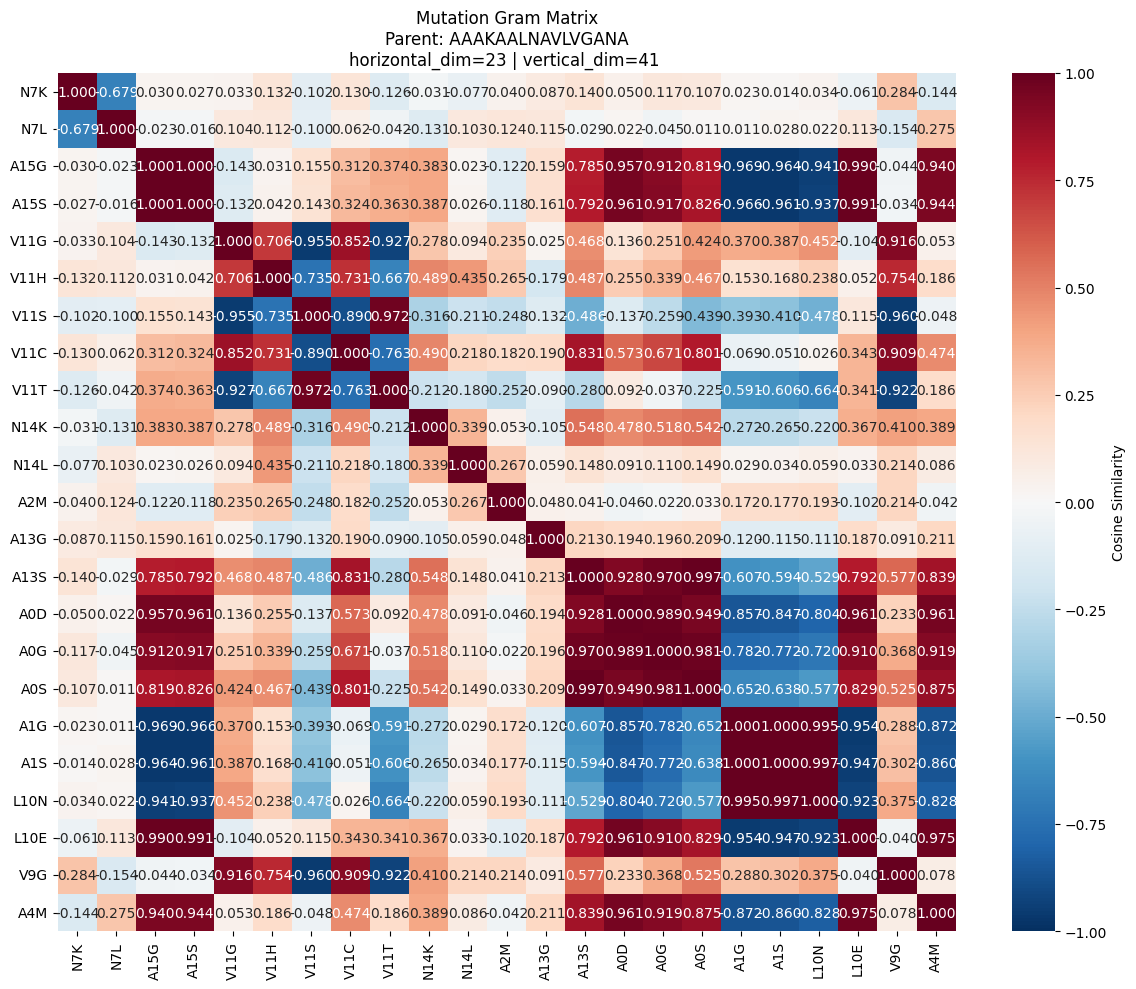

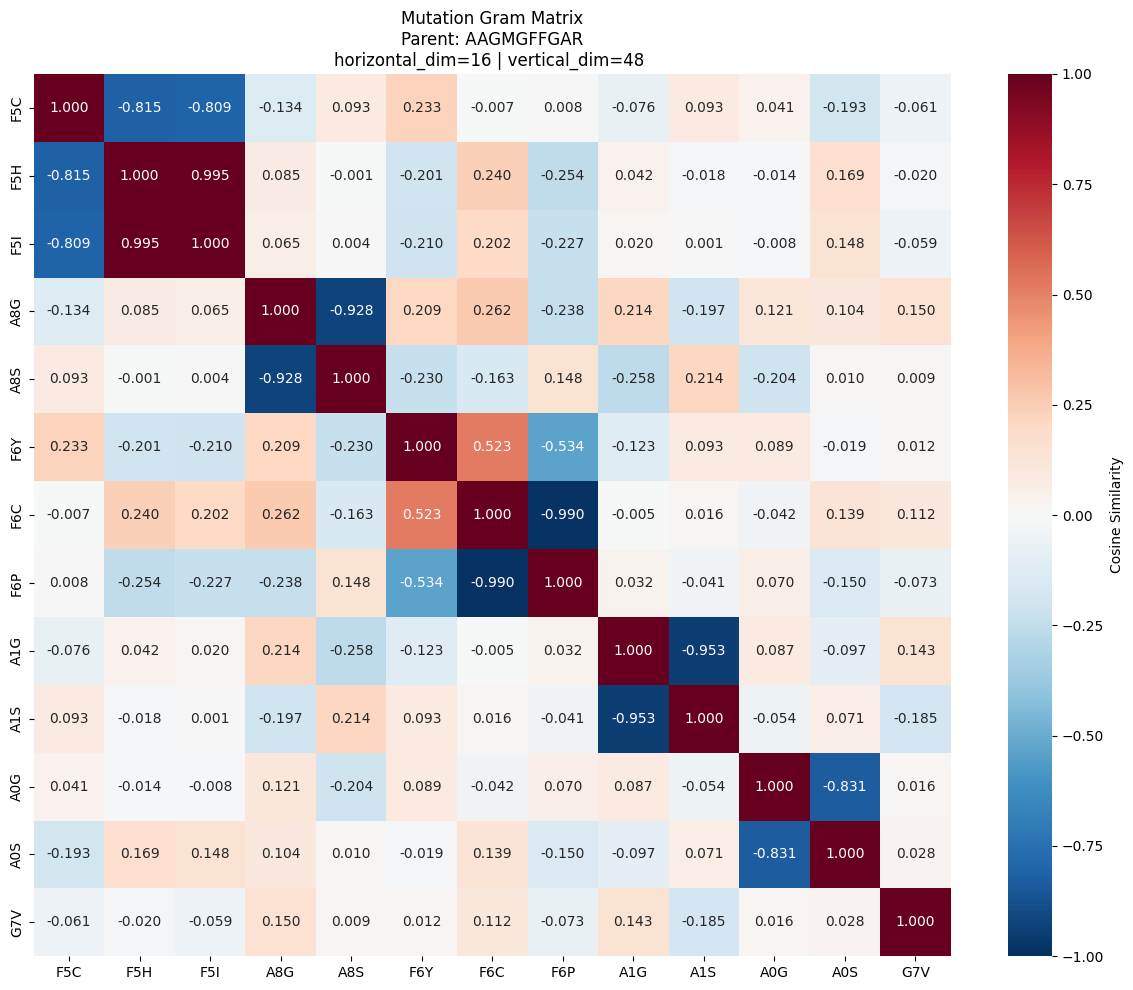

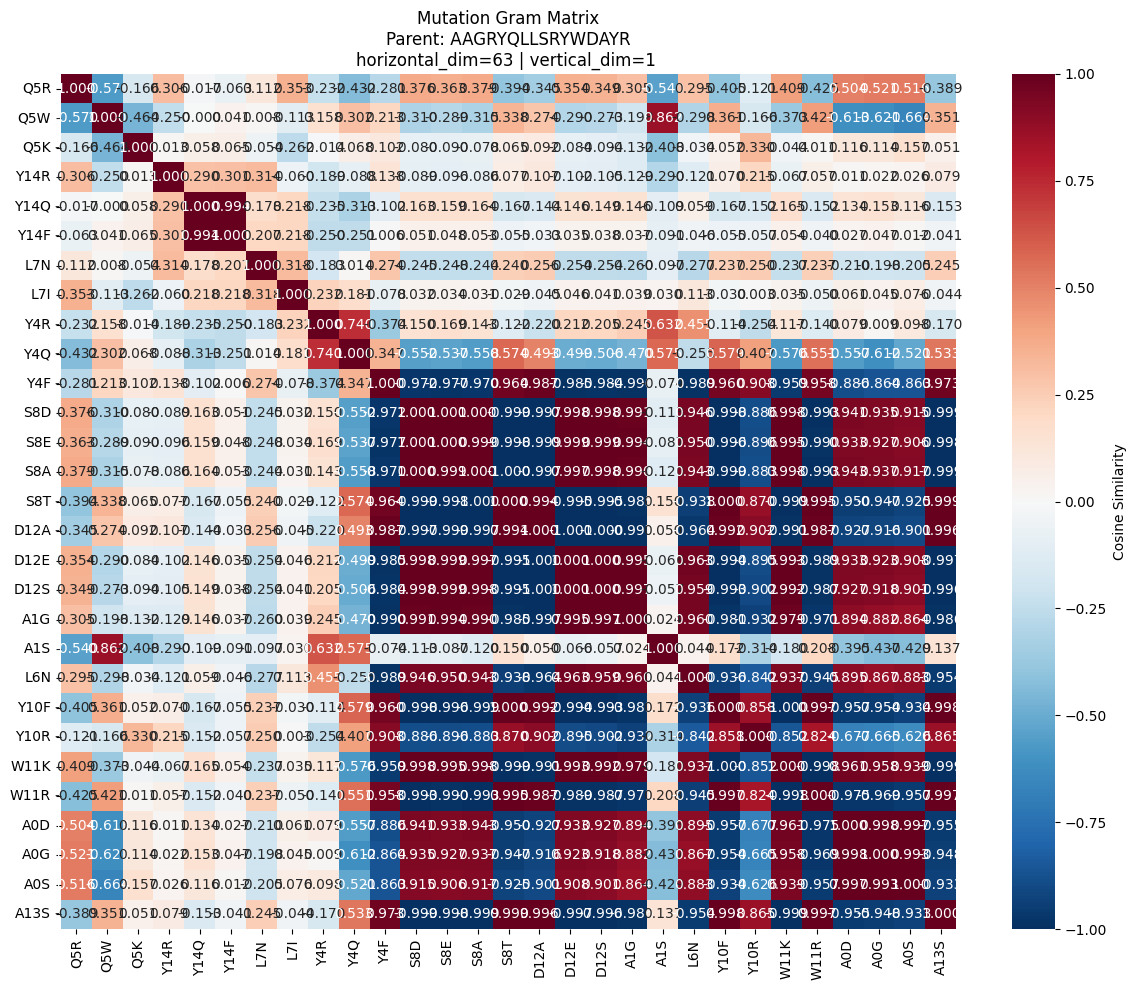

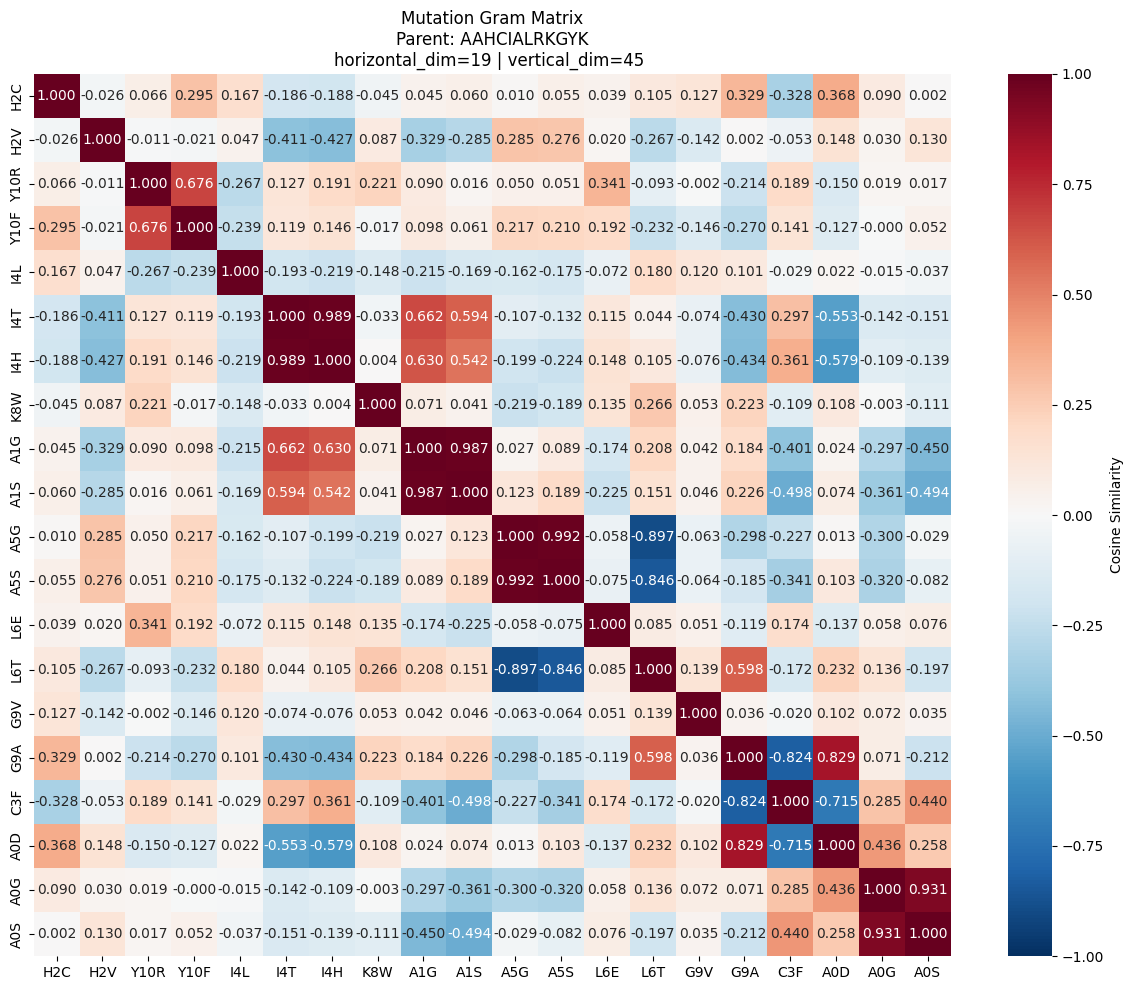

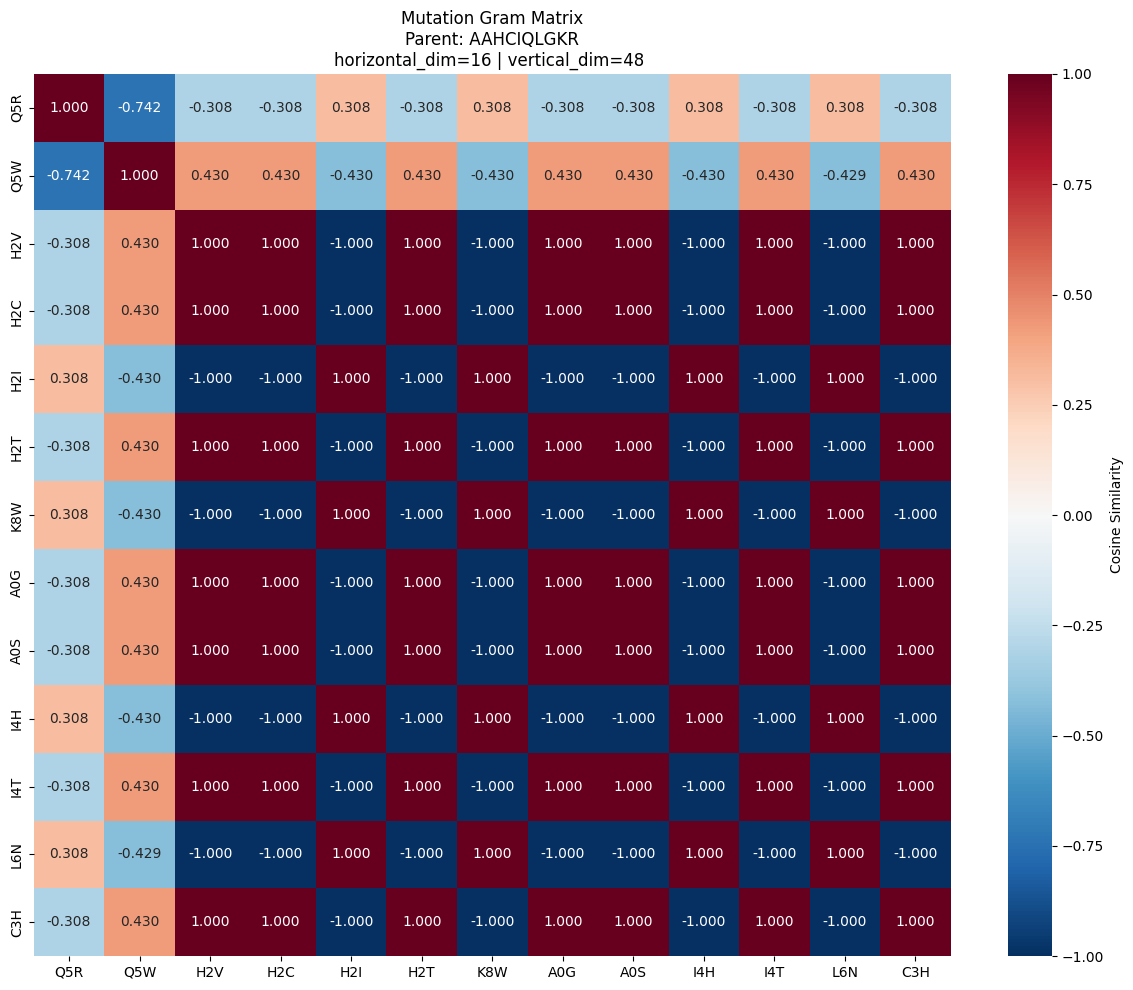

IndexError: list index out of range

In [ ]:
tables = create_all_gram_matrix_tables(all_results)

for i in range(10):
    parent_seq, gram_df, meta = tables[i]

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        gram_df,
        annot=True,
        fmt=".3f",
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        cbar_kws={"label": "Cosine Similarity"},
    )
    plt.title(
        f"Mutation Gram Matrix\nParent: {parent_seq}\n"
        f"horizontal_dim={meta['horizontal_dim']} | "
        f"vertical_dim={meta['vertical_dim']} "
        # f"latent_dim={meta['latent_dim']}"
    )
    plt.tight_layout()
    plt.show()

##secind time

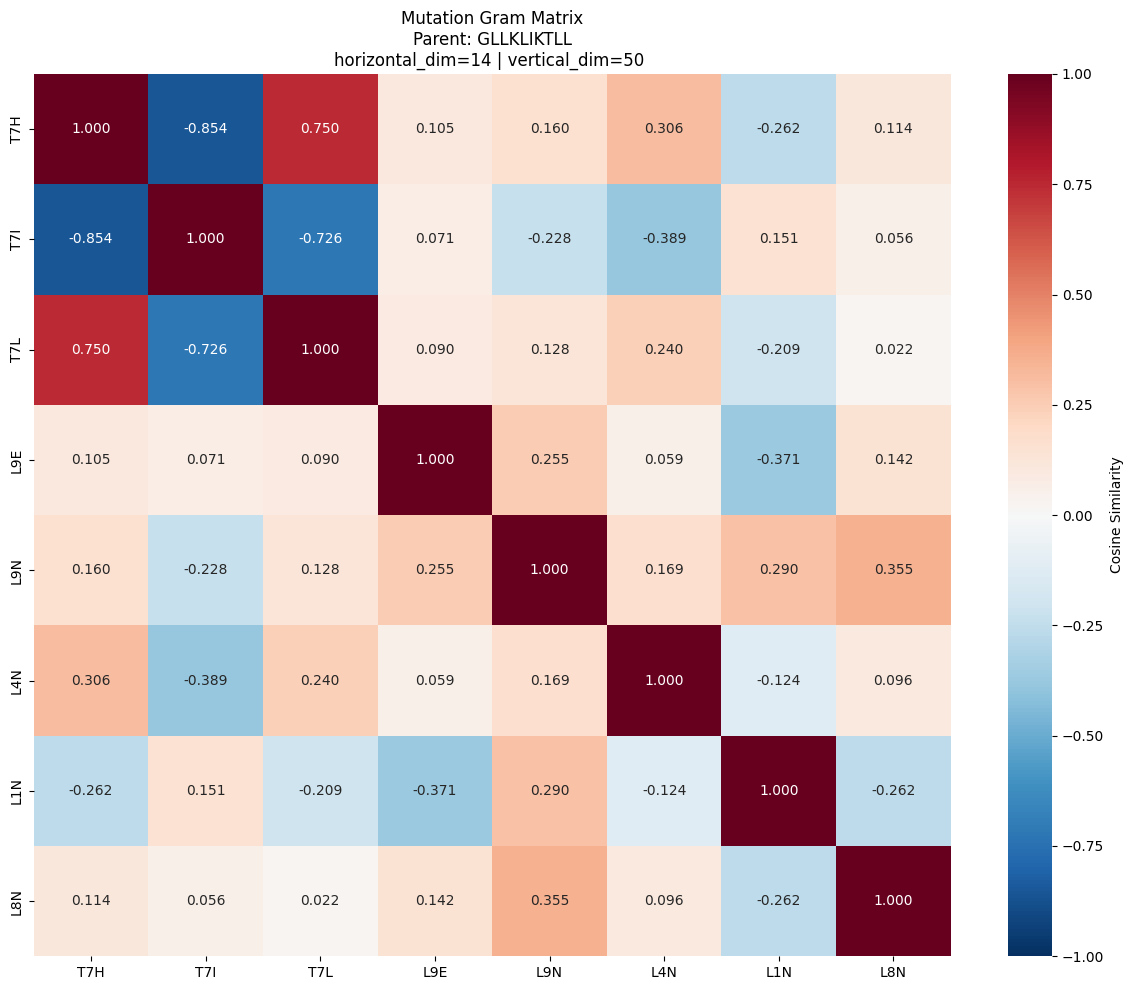

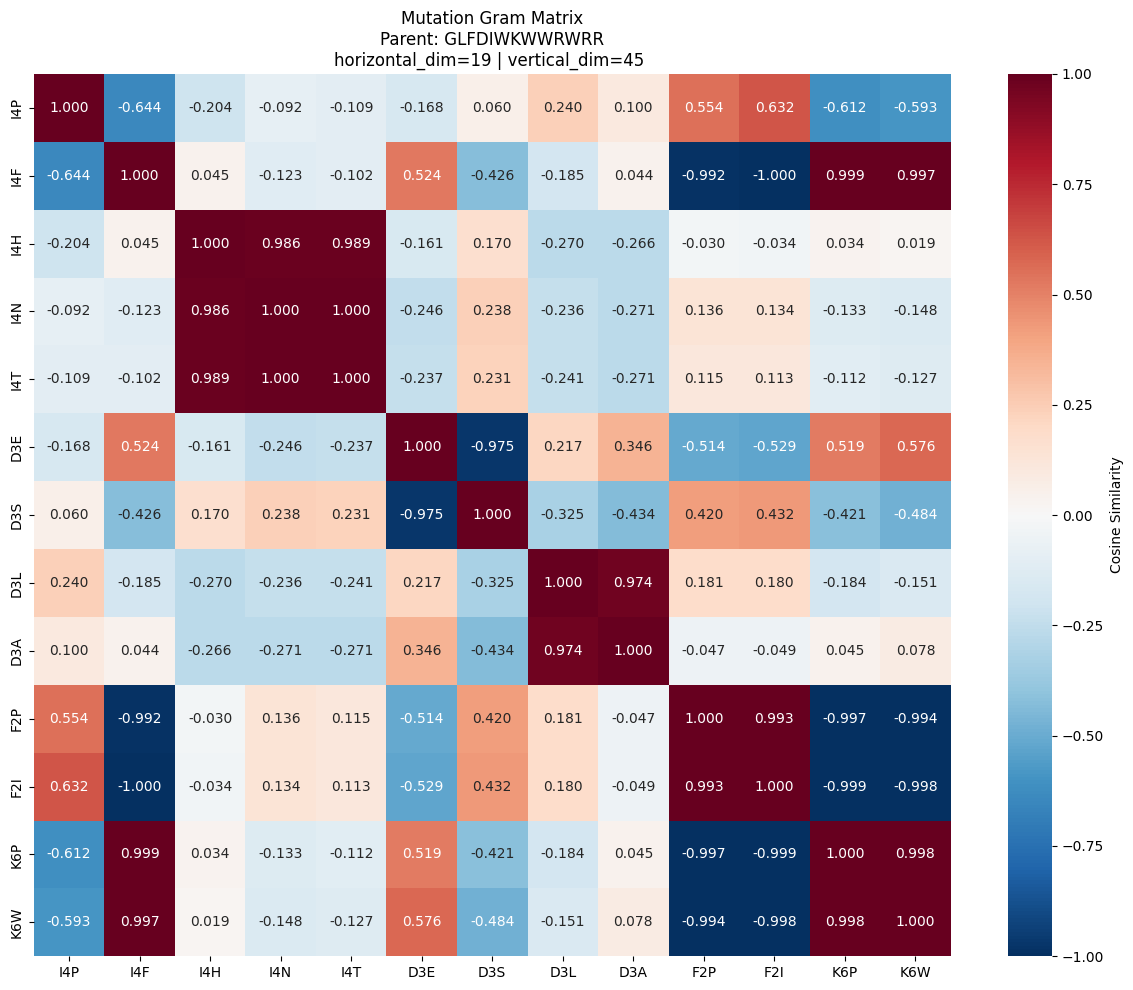

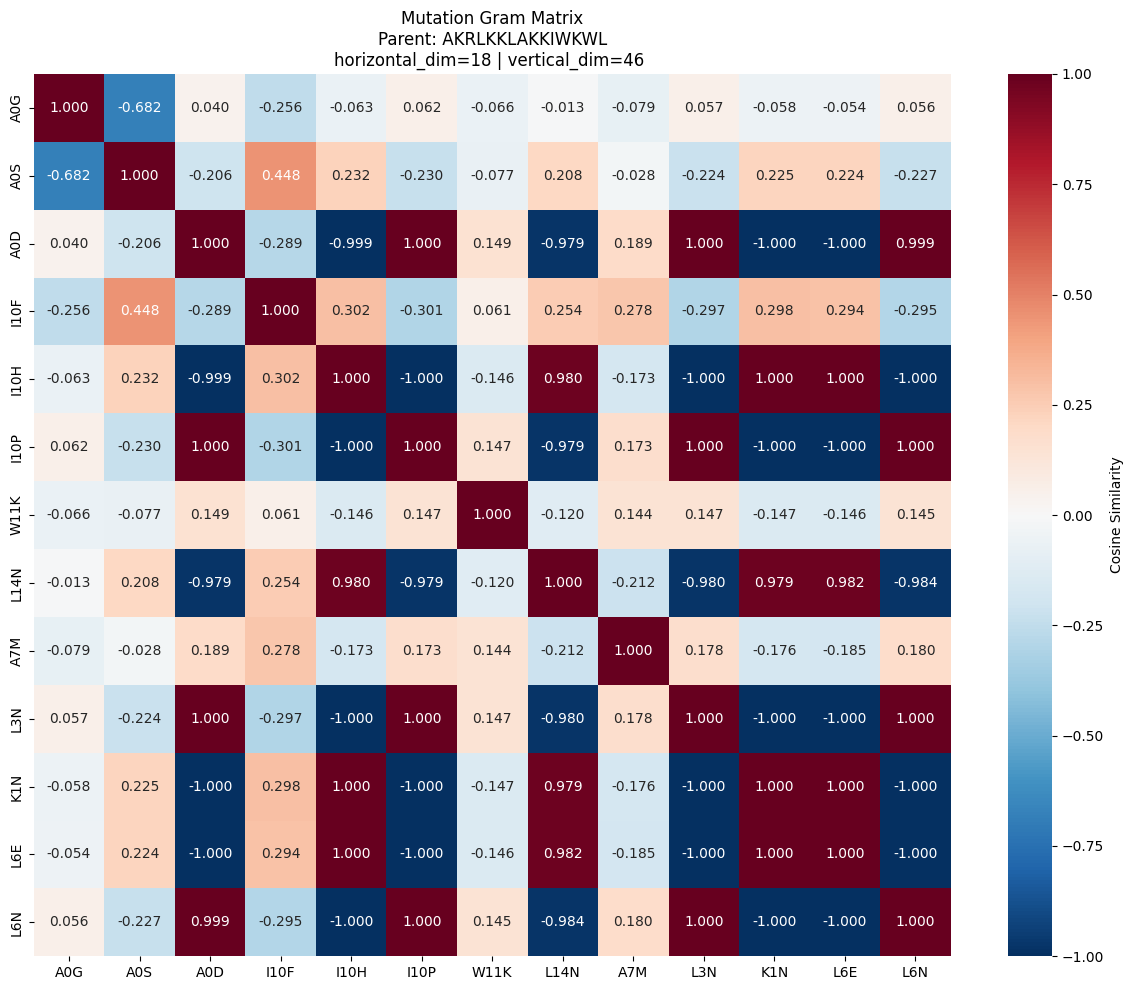

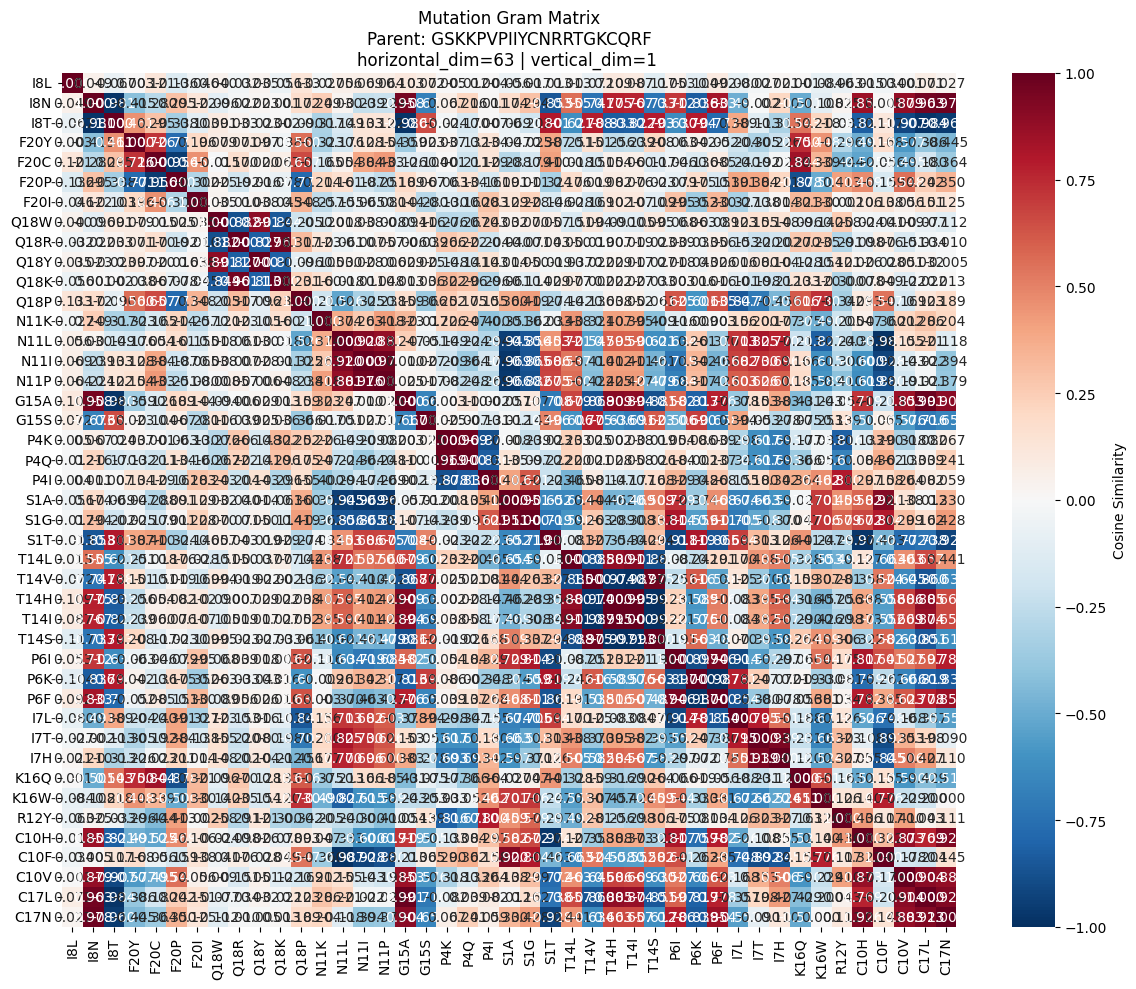

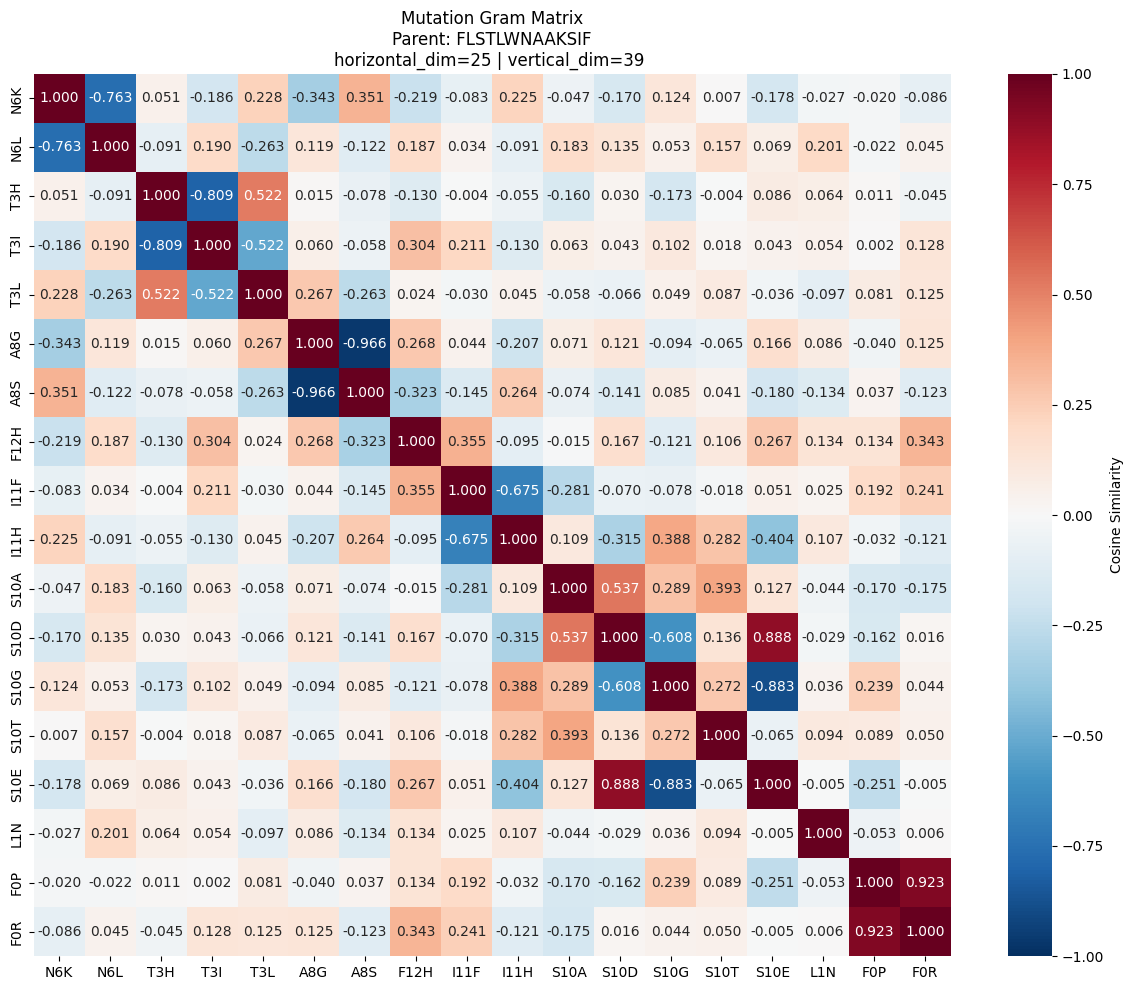

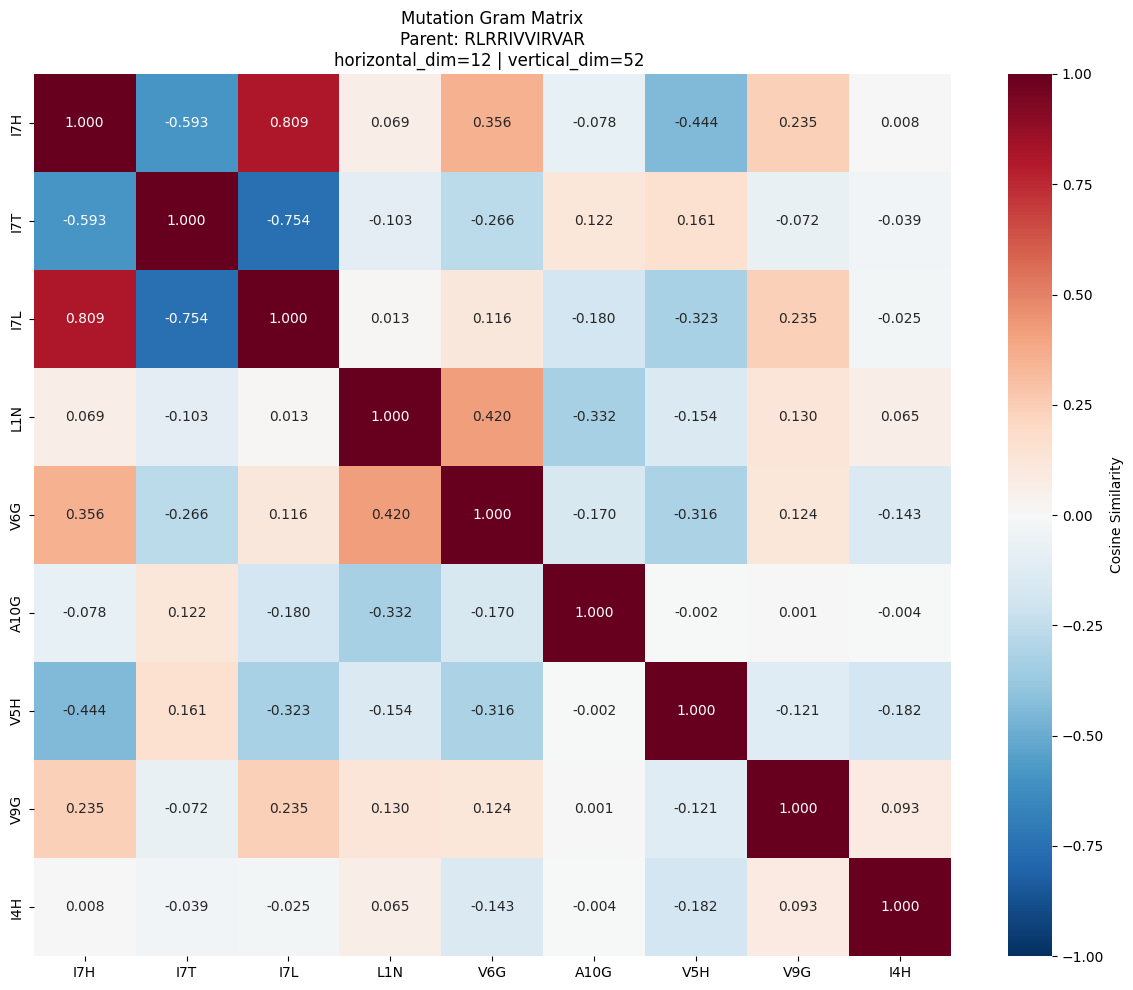

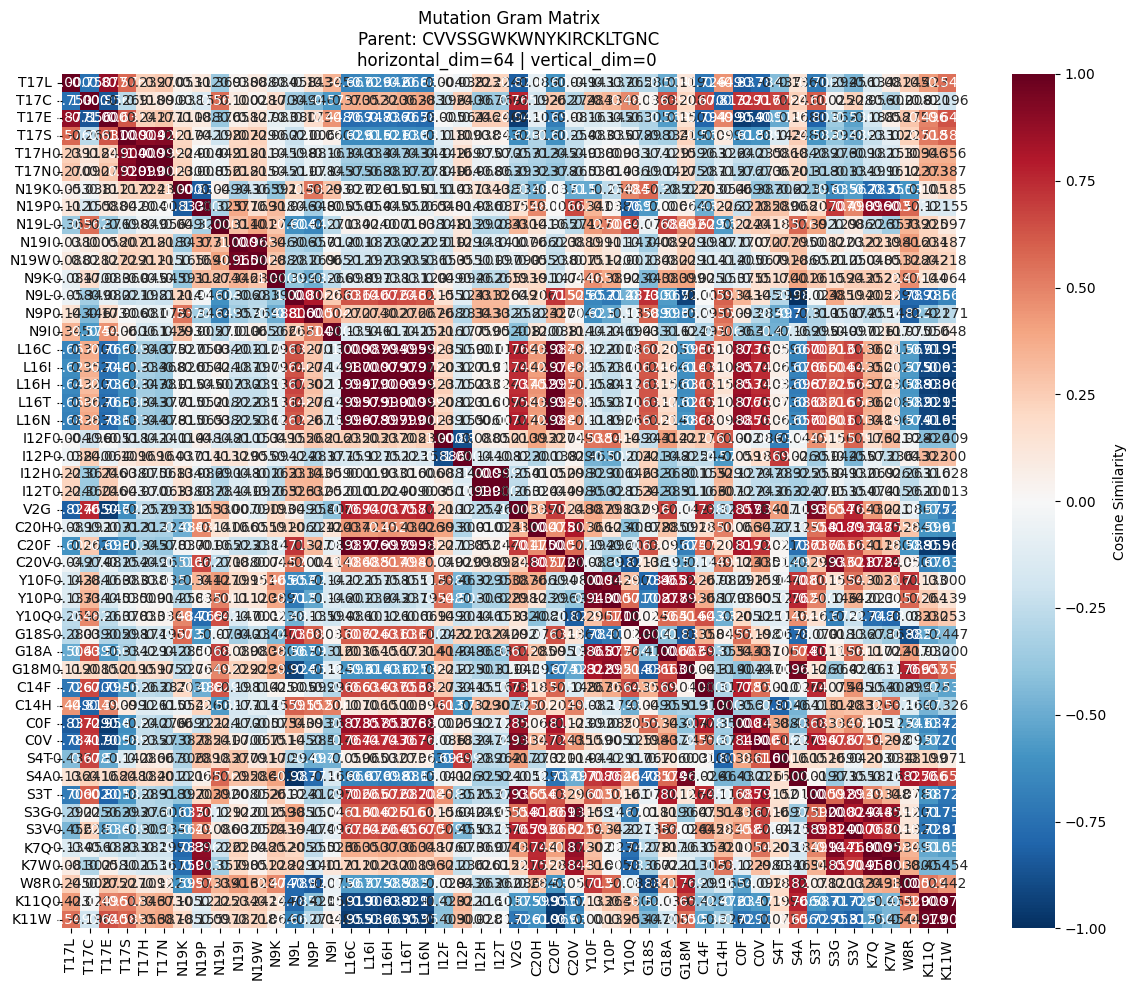

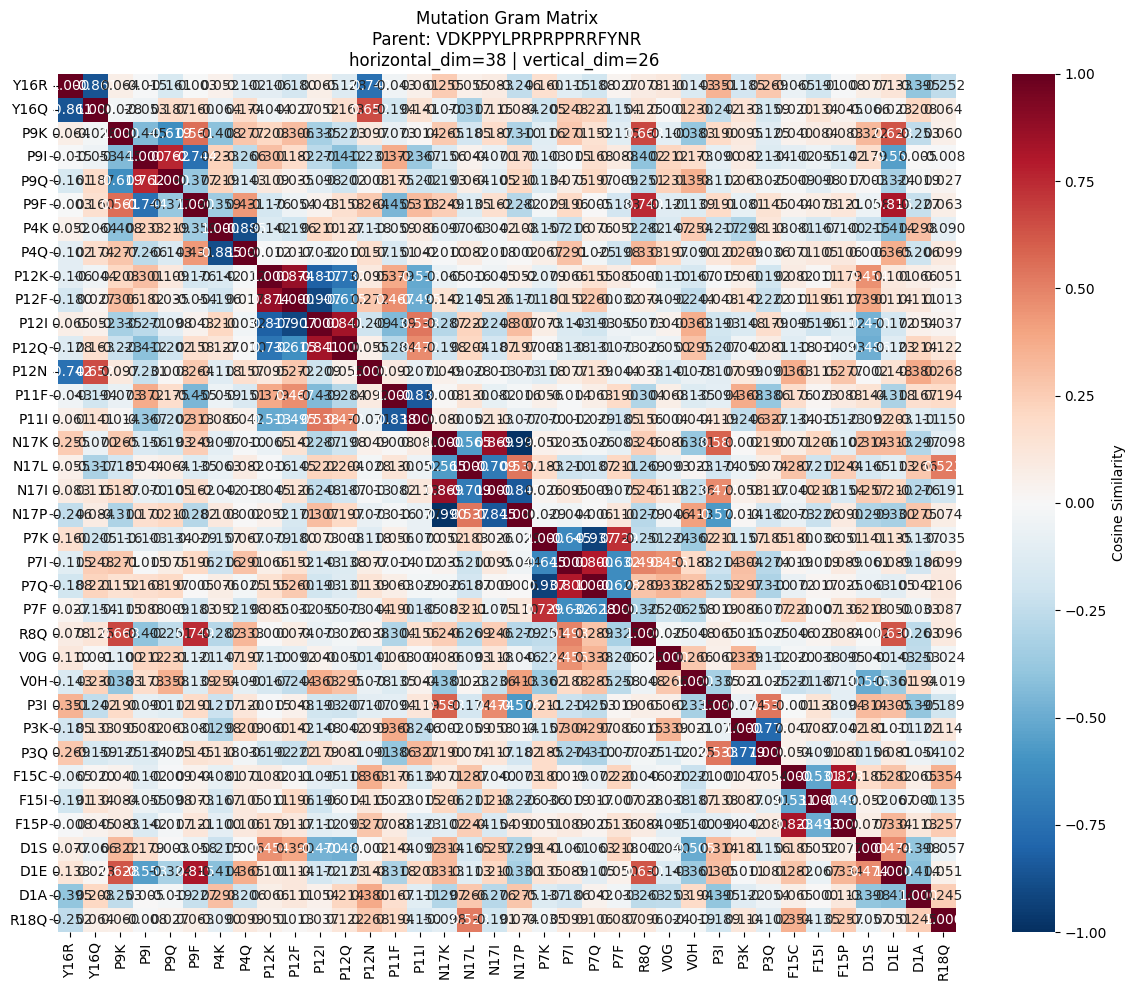

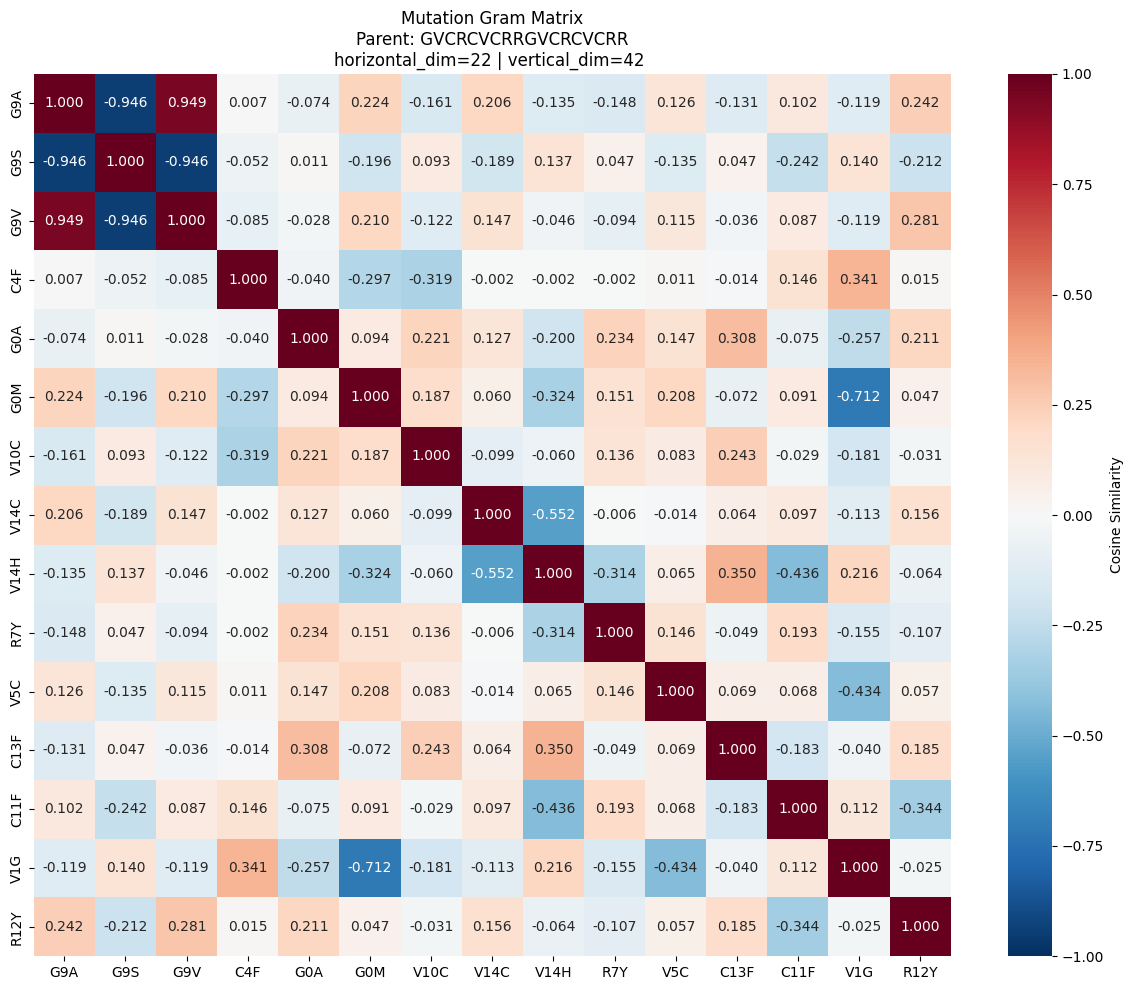

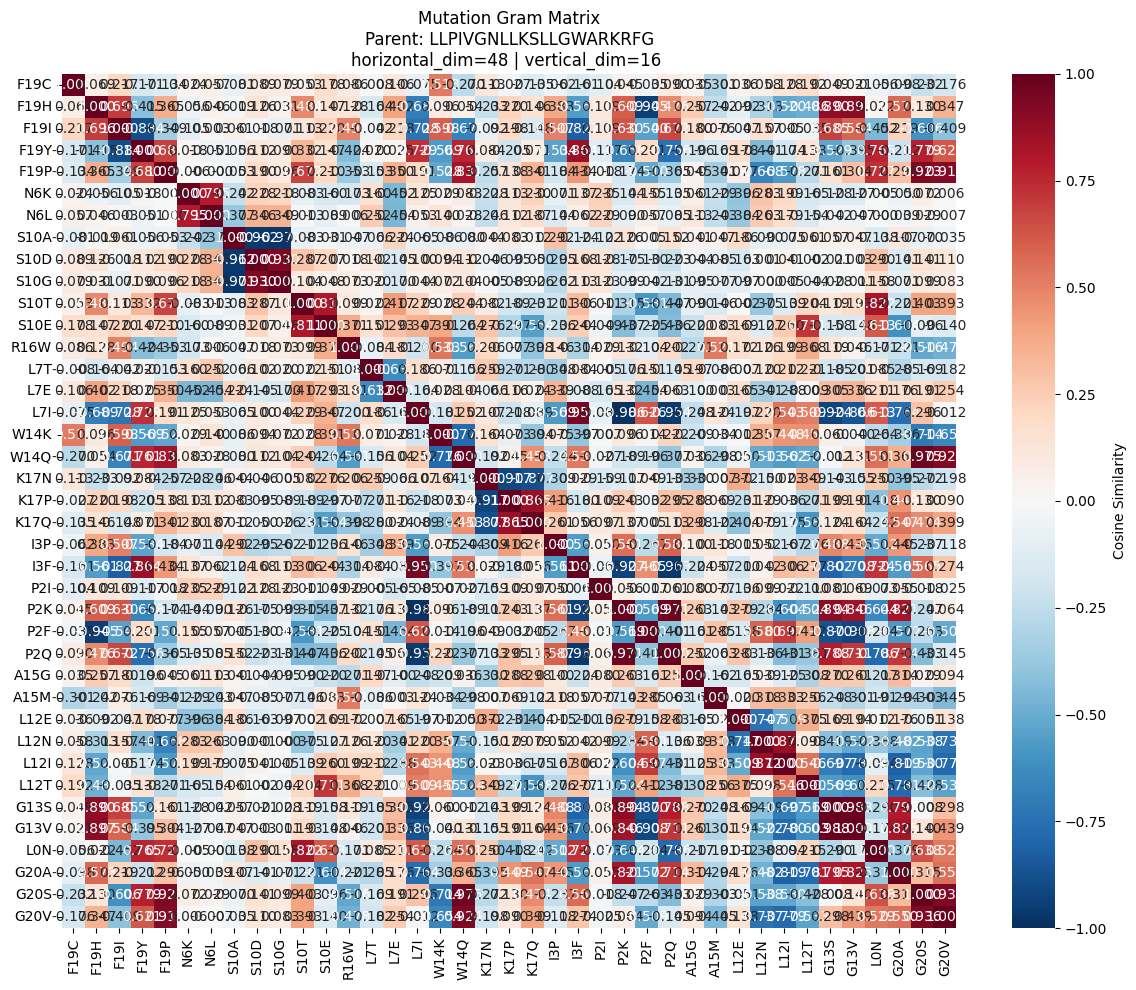

In [ ]:
csv_path = "/home/kjurasz/pep-compass/results/mutants/mutants/hydramp/dbaasp/all/high_saureus_activity_parentleq25_direction_threshold=1e-06_token_threshold=0.1_jacobian_mode=approx_jacobian_eps=0.05_leq25.csv"
n_parents = 10
mutations, parents = get_mutations_from_csv_for_n_parents(n_parents, csv_path)
all_results = compute_all_mutation_gram_matrices(
    parents, mutations, encoder_decoder, horizontal_threshold=1e-6, device=device
)


def create_gram_matrix_table(result):
    """
    Creates a pandas DataFrame from a result dict with mutation labels as both index and columns.

    Args:
        result: dict with keys 'gram_matrix' (numpy array) and 'mutation_labels' (list of strings)

    Returns:
        pd.DataFrame: Gram matrix with mutation labels
    """
    gram_matrix = result["gram_matrix"]
    mutation_labels = result["mutation_labels"]

    df = pd.DataFrame(gram_matrix, index=mutation_labels, columns=mutation_labels)

    return df


def create_all_gram_matrix_tables(all_results):
    """
    Returns list of tuples:
      (parent_seq, gram_df, metadata_dict)
    """
    tables = []

    for result in all_results:
        parent_seq = result["parent"]
        gram_df = create_gram_matrix_table(result)

        metadata = {
            "horizontal_dim": result["horizontal_dim"],
            "vertical_dim": result["vertical_dim"],
            # "latent_dim": result["latent_dim"],
        }

        tables.append((parent_seq, gram_df, metadata))

    return tables


tables = create_all_gram_matrix_tables(all_results)

for i in range(10):
    parent_seq, gram_df, meta = tables[i]

    # print(f"Parent: {parent_seq}")
    # print(f"Horizontal dim: {meta['horizontal_dim']}")
    # print(f"Vertical dim:   {meta['vertical_dim']}")
    # print(f"Latent dim:     {meta['latent_dim']}\n")

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        gram_df,
        annot=True,
        fmt=".3f",
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        cbar_kws={"label": "Cosine Similarity"},
    )
    plt.title(
        f"Mutation Gram Matrix\nParent: {parent_seq}\n"
        f"horizontal_dim={meta['horizontal_dim']} | "
        f"vertical_dim={meta['vertical_dim']} "
        # f"latent_dim={meta['latent_dim']}"
    )
    plt.tight_layout()
    plt.show()

Inspection